In [1]:
import pandas as pd
import numpy as np
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
root_path = Path().resolve().parent.parent

sys.path.append(str(root_path))

from utils.eda import summary_stats, missing_report, outlier_report, class_balance, correlation_matrix
from utils.visualization import plot_distributions, plot_boxplot, plot_class_balance

In [14]:
df = pd.read_csv(root_path / "titanic survival prediction" / "data" / "Titanic-Dataset.csv")
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [7]:
summary_stats(df)

SHAPE        : 891 rows × 12 columns

── DTYPES ──
               dtype  nunique                   sample
PassengerId    int64      891                        1
Survived       int64        2                        0
Pclass         int64        3                        3
Name          object      891  Braund, Mr. Owen Harris
Sex           object        2                     male
Age          float64       88                     22.0
SibSp          int64        7                        1
Parch          int64        7                        0
Ticket        object      681                A/5 21171
Fare         float64      248                     7.25
Cabin         object      147                      NaN
Embarked      object        3                        S


In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
missing_report(df)

MISSING VALUE REPORT  (total kolom: 12)
          missing_count  missing_pct    dtype
Cabin               687        77.10   object
Age                 177        19.87  float64
Embarked              2         0.22   object


In [15]:
print(f"Jumlah data duplikat: {df.duplicated().sum()}")

Jumlah data duplikat: 0


In [11]:
outlier_report(df)

OUTLIER REPORT  (method=iqr)
column  n_outliers  pct_outliers  has_outlier  lower_bound  upper_bound
 Parch         213         23.91         True       0.0000       0.0000
  Fare         116         13.02         True     -26.7240      65.6344
 SibSp          46          5.16         True      -1.5000       2.5000
   Age          11          1.54         True      -6.6875      64.8125

Kolom dengan outlier: 4 / 7


In [13]:
class_balance(df, 'Survived')

CLASS BALANCE — 'Survived'
          count    pct
Survived              
0           549  61.62
1           342  38.38

Imbalance ratio (max/min): 1.61x
✓  Dataset relatif balanced.


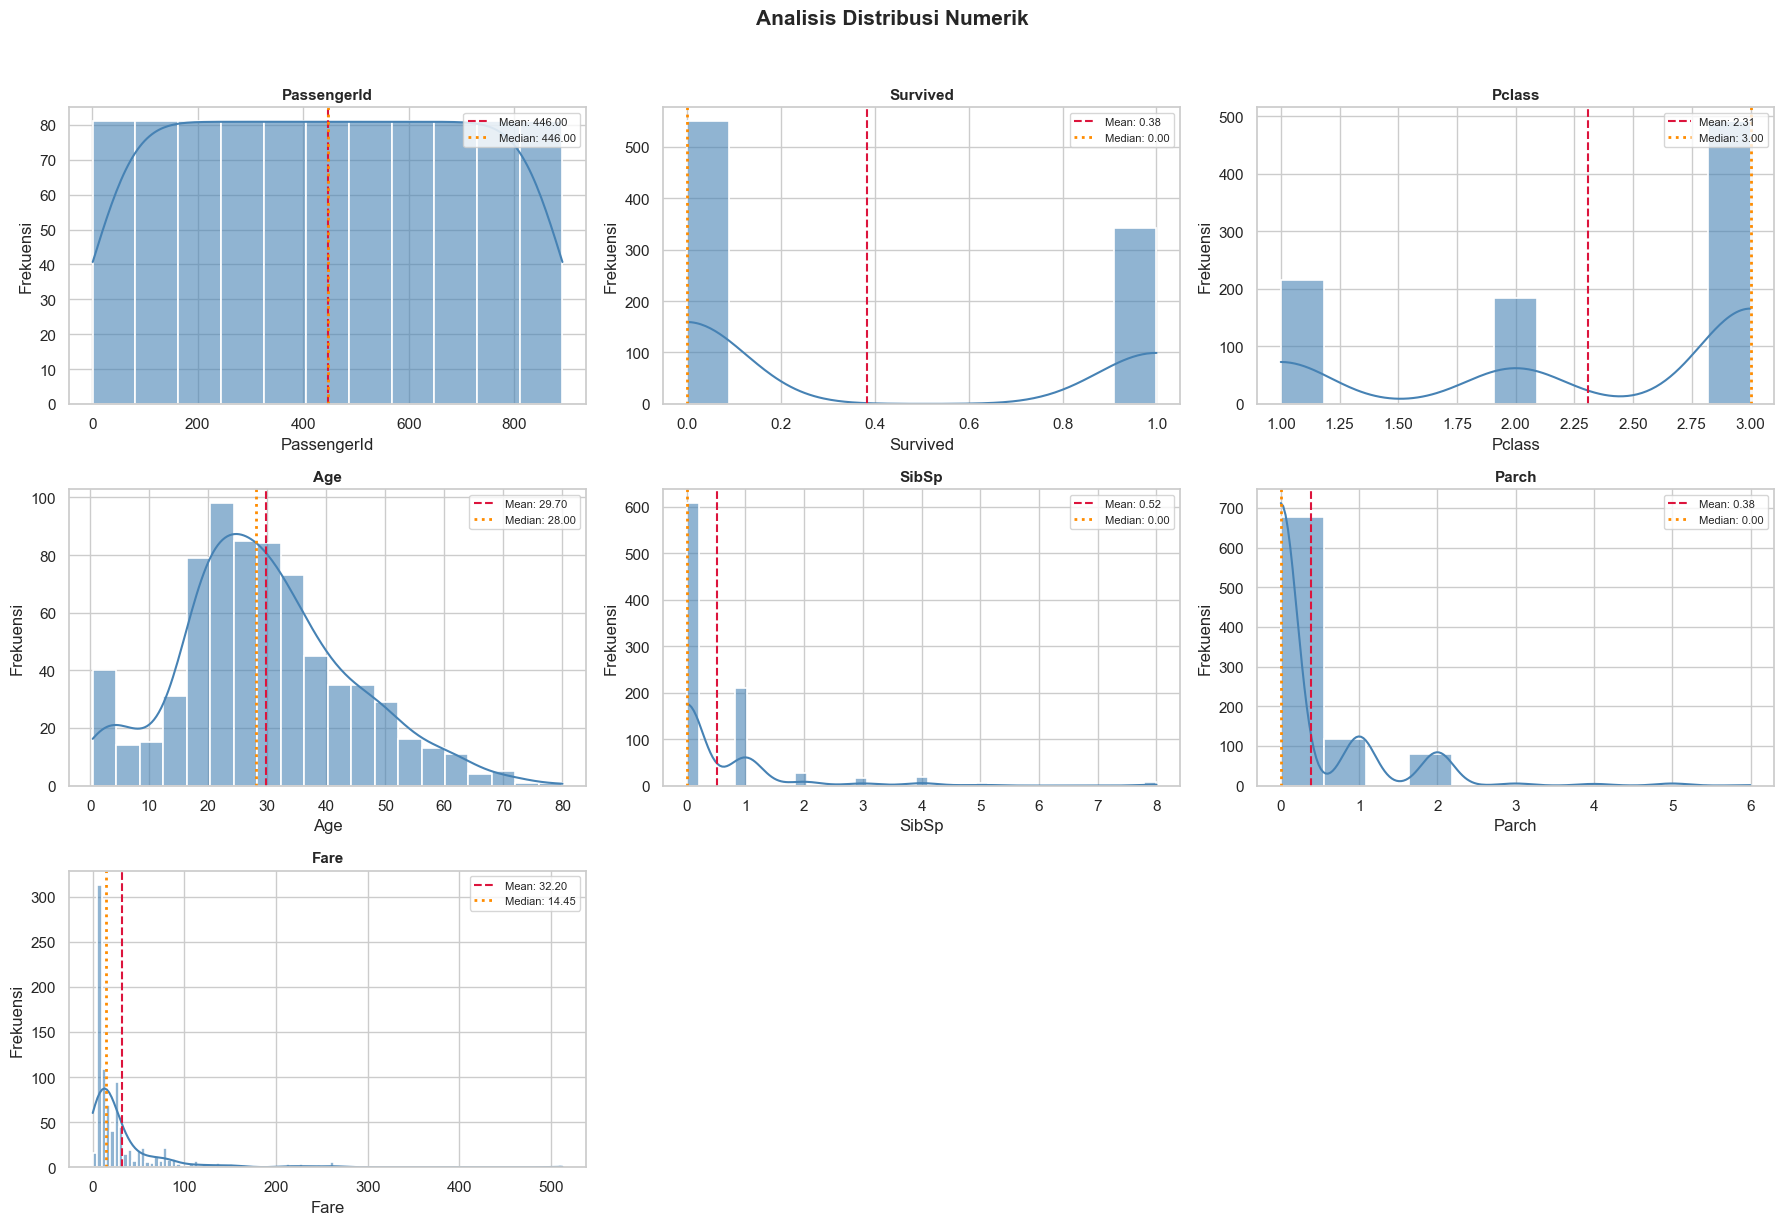

In [25]:
fitur_numeric = df.select_dtypes(include='number').columns.tolist()
plot_distributions(df, fitur_numeric)

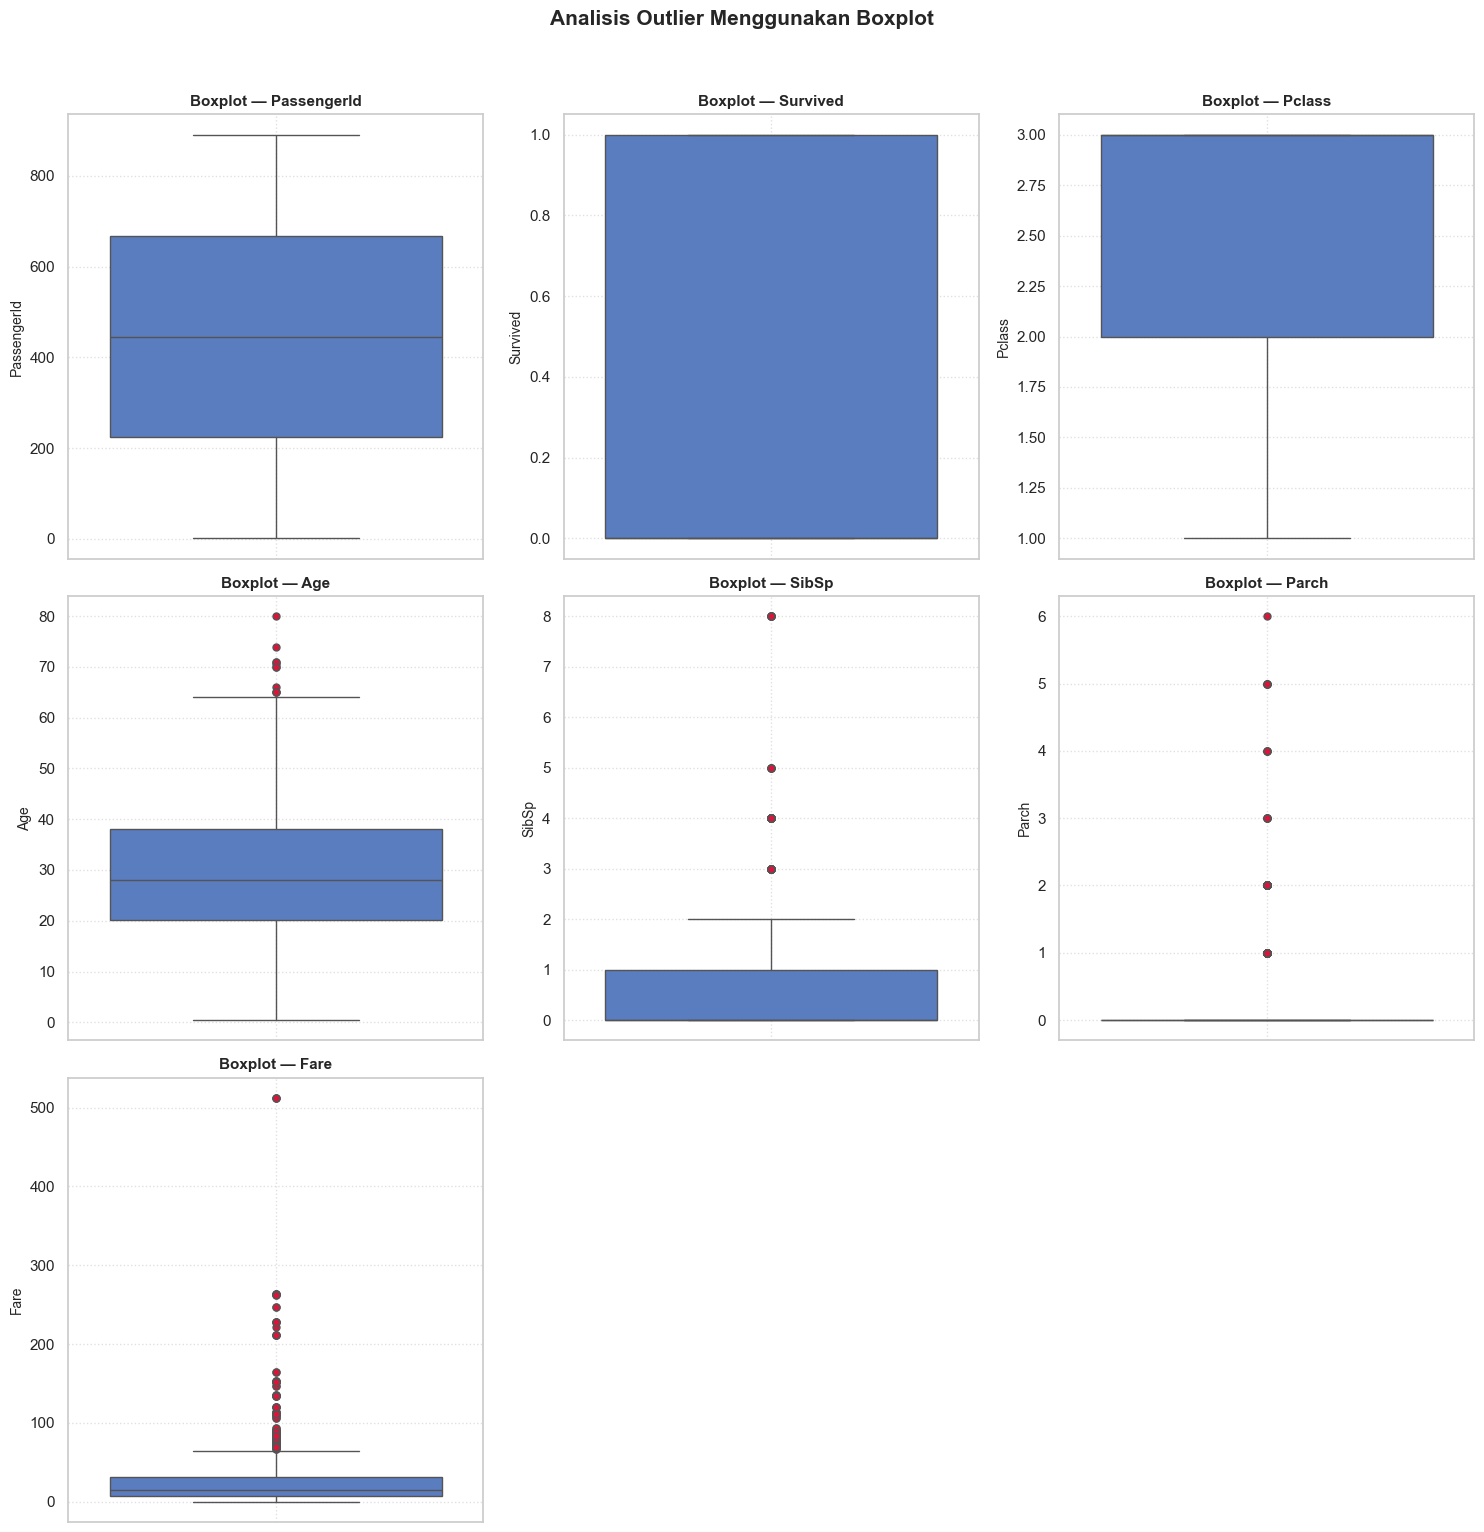

In [26]:
plot_boxplot(df, fitur_numeric)

C:\Users\aril\AppData\Local\Temp\ipykernel_2960\2567273459.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(df, y='Age', order = df['Age'].value_counts().index,


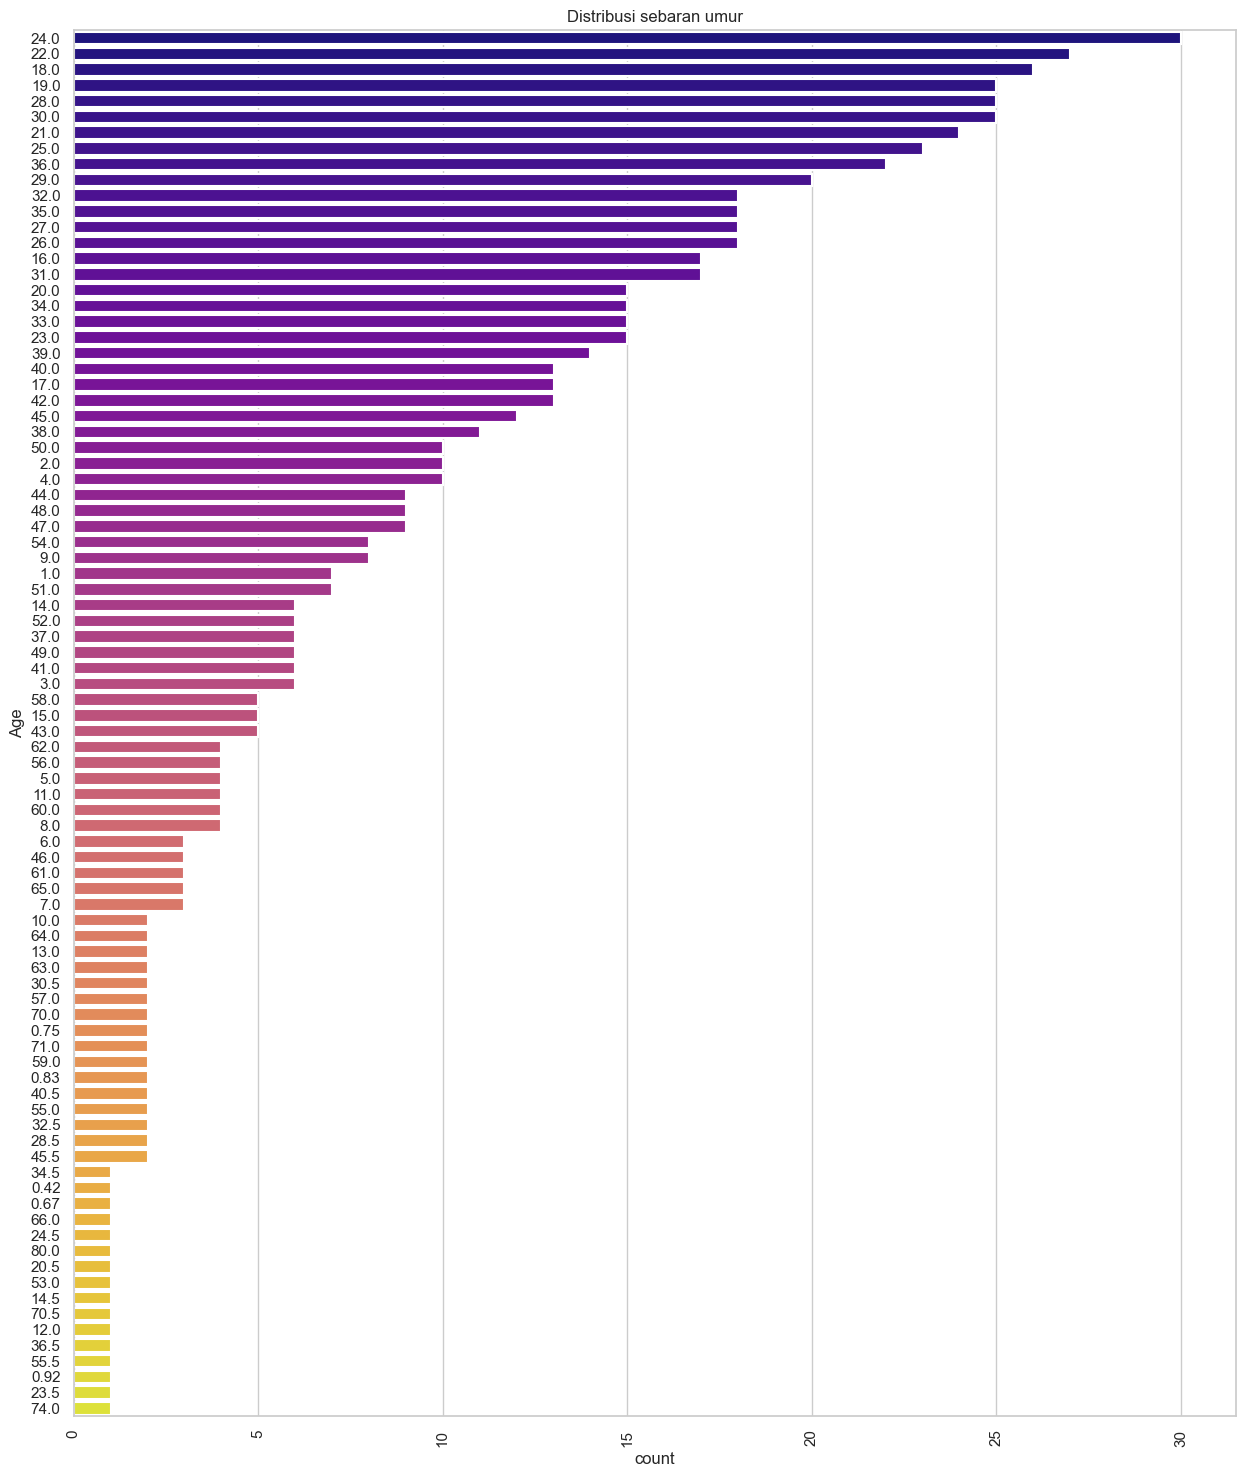

In [39]:
plt.figure(figsize=(15, 18))
sns.countplot(df, y='Age', order = df['Age'].value_counts().index,
             palette='plasma',
              edgecolor='white',     
              linewidth=1.5,         
              saturation=0.8,       
              width=0.8
             )
plt.xticks(rotation=90)
plt.title("Distribusi sebaran umur")
plt.show()

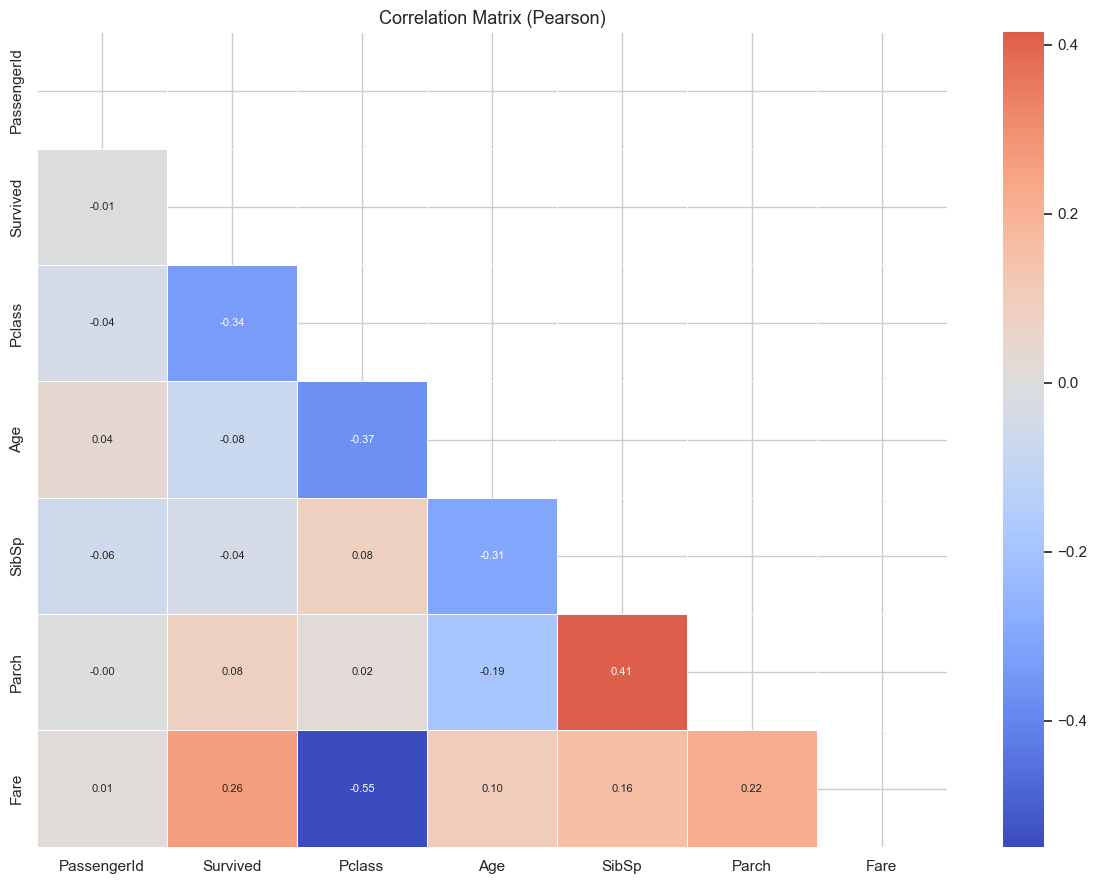

In [40]:
correlation_matrix(df)